In [1]:
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
import cv2
tf.__version__

2025-05-27 18:19:12.919226: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1748369953.119737      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1748369953.179176      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


'2.18.0'

In [2]:
path_dataset = r'/kaggle/input/augmented-alzheimer-mri-dataset/AugmentedAlzheimerDataset'
image_data_get =tf.keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function = tf.keras.applications.resnet50.preprocess_input,
    validation_split = 0.2
)


In [3]:
image_gen_train = image_data_get.flow_from_directory(
    path_dataset,
    target_size = (224,224),
    batch_size = 32,
    class_mode = 'categorical',
    shuffle = True,
    subset = 'training'
)
image_gen_val = image_data_get.flow_from_directory(
    path_dataset,
    target_size = (224,224),
    batch_size = 32,
    class_mode = 'categorical',
    shuffle = True,
    subset = 'validation'
)

Found 27188 images belonging to 4 classes.
Found 6796 images belonging to 4 classes.


In [4]:
image_gen_train.class_indices

{'MildDemented': 0,
 'ModerateDemented': 1,
 'NonDemented': 2,
 'VeryMildDemented': 3}

In [5]:
modelo_transfer = r'/kaggle/input/transfer-leraning/keras/default/1/resnet50_weights_tf_dim_ordering_tf_kernels_notop.h5'
transfer_model = tf.keras.applications.ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)
display("Done")

I0000 00:00:1748369981.918503      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


'Done'

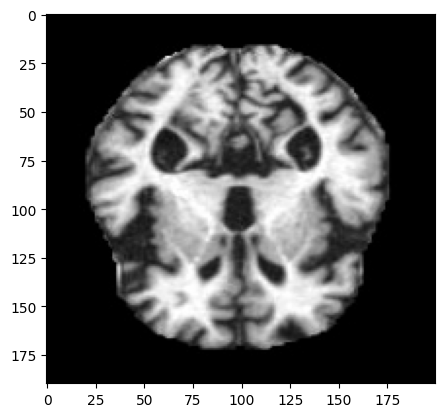

In [6]:
testing_image = r'/kaggle/input/augmented-alzheimer-mri-dataset/AugmentedAlzheimerDataset/ModerateDemented/001ef5a6-893b-4ede-9cf8-60b7fb94a541.jpg'

plt.imshow(plt.imread(testing_image))

In [7]:
for i, layers in enumerate(transfer_model.layers):
  print(i, layers)

0 <InputLayer name=input_layer, built=True>
1 <ZeroPadding2D name=conv1_pad, built=True>
2 <Conv2D name=conv1_conv, built=True>
3 <BatchNormalization name=conv1_bn, built=True>
4 <Activation name=conv1_relu, built=True>
5 <ZeroPadding2D name=pool1_pad, built=True>
6 <MaxPooling2D name=pool1_pool, built=True>
7 <Conv2D name=conv2_block1_1_conv, built=True>
8 <BatchNormalization name=conv2_block1_1_bn, built=True>
9 <Activation name=conv2_block1_1_relu, built=True>
10 <Conv2D name=conv2_block1_2_conv, built=True>
11 <BatchNormalization name=conv2_block1_2_bn, built=True>
12 <Activation name=conv2_block1_2_relu, built=True>
13 <Conv2D name=conv2_block1_0_conv, built=True>
14 <Conv2D name=conv2_block1_3_conv, built=True>
15 <BatchNormalization name=conv2_block1_0_bn, built=True>
16 <BatchNormalization name=conv2_block1_3_bn, built=True>
17 <Add name=conv2_block1_add, built=True>
18 <Activation name=conv2_block1_out, built=True>
19 <Conv2D name=conv2_block2_1_conv, built=True>
20 <BatchNorm

In [8]:
x = transfer_model.output

In [9]:
x = tf.keras.layers.GlobalAveragePooling2D()(x)

x = tf.keras.layers.Dense(1024, activation='relu')(x)
x = tf.keras.layers.Dense(1024, activation='relu')(x)
x = tf.keras.layers.Dense(1024, activation='relu')(x)

x = tf.keras.layers.Dropout(0.5)(x)

x = tf.keras.layers.Dense(512, activation='relu')(x)
preds = tf.keras.layers.Dense(4, activation='softmax')(x)

In [10]:
model = tf.keras.models.Model(inputs=transfer_model.input, outputs=preds)

In [11]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 224, 224, 3)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_pad (ZeroPadding2D) │ (None, 230, 230, 3)    │              0 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_conv (Conv2D)       │ (None, 112, 112, 64)   │          9,472 │ conv1_pad[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_bn                  │ (None, 112, 112, 64)   │            256 │ conv1_conv[0][0]       │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_relu (Activation)   │ (None, 112, 112, 64)   │              0 │ conv1_bn[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ pool1_pad (ZeroPadding2D) │ (None, 114, 114, 64)   │              0 │ conv1_relu[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ pool1_pool (MaxPooling2D) │ (None, 56, 56, 64)     │              0 │ pool1_pad[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_conv       │ (None, 56, 56, 64)     │          4,160 │ pool1_pool[0][0]       │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_bn         │ (None, 56, 56, 64)     │            256 │ conv2_block1_1_conv[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_relu       │ (None, 56, 56, 64)     │              0 │ conv2_block1_1_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_conv       │ (None, 56, 56, 64)     │         36,928 │ conv2_block1_1_relu[0… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_bn         │ (None, 56, 56, 64)     │            256 │ conv2_block1_2_conv[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_relu       │ (None, 56, 56, 64)     │              0 │ conv2_block1_2_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_0_conv       │ (None, 56, 56, 256)    │         16,640 │ pool1_pool[0][0]       │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_3_conv       │ (None, 56, 56, 256)    │         16,640 │ conv2_block1_2_relu[0… │
│ (Conv2D)                  │                        │                │                        │
├──────────────────────

 Total params: 28,311,940 (108.00 MB)

 Trainable params: 28,258,820 (107.80 MB)

 Non-trainable params: 53,120 (207.50 KB)

(-0.5, 223.5, 223.5, -0.5)

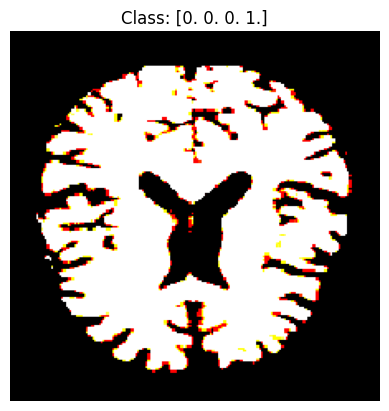

In [12]:
imagem, label = image_gen_train[1][0][0], image_gen_train[1][1][0]
plt.imshow(imagem)
plt.title(f"Class: {label}")
plt.axis('off')


In [13]:
image_gen_train[1][0][0]

array([[[-103.939, -116.779, -123.68 ],
        [-103.939, -116.779, -123.68 ],
        [-103.939, -116.779, -123.68 ],
        ...,
        [-103.939, -116.779, -123.68 ],
        [-103.939, -116.779, -123.68 ],
        [-103.939, -116.779, -123.68 ]],

       [[-103.939, -116.779, -123.68 ],
        [-103.939, -116.779, -123.68 ],
        [-103.939, -116.779, -123.68 ],
        ...,
        [-103.939, -116.779, -123.68 ],
        [-103.939, -116.779, -123.68 ],
        [-103.939, -116.779, -123.68 ]],

       [[-103.939, -116.779, -123.68 ],
        [-103.939, -116.779, -123.68 ],
        [-103.939, -116.779, -123.68 ],
        ...,
        [-103.939, -116.779, -123.68 ],
        [-103.939, -116.779, -123.68 ],
        [-103.939, -116.779, -123.68 ]],

       ...,

       [[-103.939, -116.779, -123.68 ],
        [-103.939, -116.779, -123.68 ],
        [-103.939, -116.779, -123.68 ],
        ...,
        [-103.939, -116.779, -123.68 ],
        [-103.939, -116.779, -123.68 ],
        [

In [14]:
model.compile(optimizer=tf.keras.optimizers.RMSprop(0.0001, decay=1e-6), loss='categorical_crossentropy',metrics=['accuracy'])
hist = model.fit(image_gen_train, validation_data=image_gen_train, epochs = 10, batch_size=512)

/usr/local/lib/python3.11/dist-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10


I0000 00:00:1748370018.099465      72 service.cc:148] XLA service 0x7c20d4016670 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1748370018.100356      72 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1748370021.374185      72 cuda_dnn.cc:529] Loaded cuDNN version 90300


  1/850 ━━━━━━━━━━━━━━━━━━━━ 12:30:23 53s/step - accuracy: 0.2188 - loss: 1.4246

I0000 00:00:1748370039.178012      72 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


850/850 ━━━━━━━━━━━━━━━━━━━━ 271s 257ms/step - accuracy: 0.6891 - loss: 0.6868 - val_accuracy: 0.6010 - val_loss: 9.4516
Epoch 2/10
850/850 ━━━━━━━━━━━━━━━━━━━━ 185s 218ms/step - accuracy: 0.9554 - loss: 0.1302 - val_accuracy: 0.9131 - val_loss: 0.3450
Epoch 3/10
850/850 ━━━━━━━━━━━━━━━━━━━━ 187s 220ms/step - accuracy: 0.9809 - loss: 0.0629 - val_accuracy: 0.9863 - val_loss: 0.0418
Epoch 4/10
850/850 ━━━━━━━━━━━━━━━━━━━━ 185s 218ms/step - accuracy: 0.9861 - loss: 0.0448 - val_accuracy: 0.9818 - val_loss: 0.0626
Epoch 5/10
850/850 ━━━━━━━━━━━━━━━━━━━━ 183s 215ms/step - accuracy: 0.9907 - loss: 0.0317 - val_accuracy: 0.9737 - val_loss: 0.0921
Epoch 6/10
850/850 ━━━━━━━━━━━━━━━━━━━━ 188s 221ms/step - accuracy: 0.9917 - loss: 0.0281 - val_accuracy: 0.9889 - val_loss: 0.0343
Epoch 7/10
850/850 ━━━━━━━━━━━━━━━━━━━━ 184s 216ms/step - accuracy: 0.9938 - loss: 0.0201 - val_accuracy: 0.9923 - val_loss: 0.0287
Epoch 8/10
850/850 ━━━━━━━━━━━━━━━━━━━━ 184s 216ms/step - accuracy: 0.9937 - loss: 0.02

In [15]:
acc = hist.history['accuracy']
val_acc = hist.history['val_accuracy']

<Figure size 640x480 with 0 Axes>

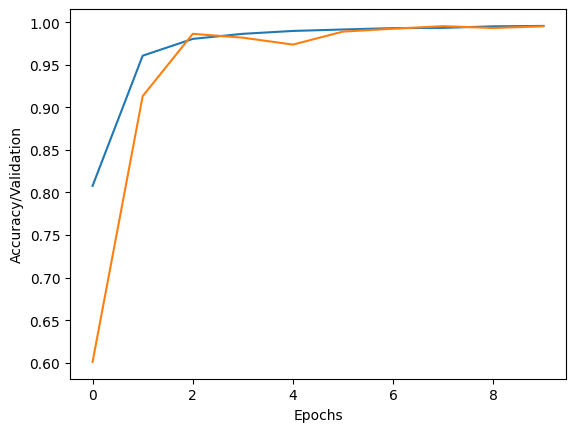

<Figure size 640x480 with 0 Axes>

In [16]:
plt.plot(acc, label='Accuracy')
plt.plot(val_acc, label="Accuracy Validation")
plt.xlabel("Epochs")
plt.ylabel("Accuracy/Validation")
plt.figure()

In [17]:
loss = hist.history['loss']
val_loss = hist.history['val_loss']

<Figure size 640x480 with 0 Axes>

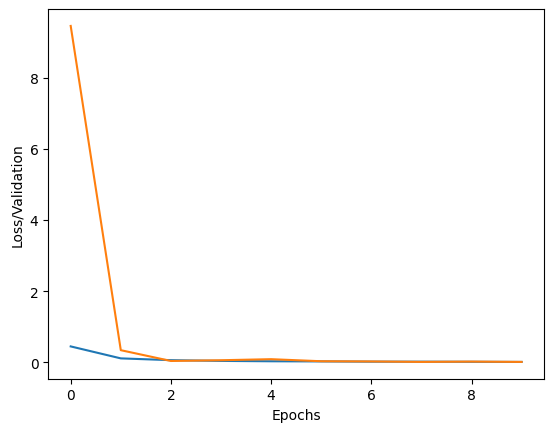

<Figure size 640x480 with 0 Axes>

In [18]:
plt.plot(loss, label='Loss')
plt.plot(val_loss, label="Loss Validation")
plt.xlabel("Epochs")
plt.ylabel("Loss/Validation")
plt.figure()

In [19]:
path_testing_dataset = r'/kaggle/input/augmented-alzheimer-mri-dataset/OriginalDataset'

In [20]:
testing_image_data_gen = tf.keras.preprocessing.image.ImageDataGenerator(  
   preprocessing_function = tf.keras.applications.resnet50.preprocess_input
)

images = testing_image_data_gen.flow_from_directory(
    path_testing_dataset,
    target_size = (224,224),
    shuffle = False
)

Found 6400 images belonging to 4 classes.


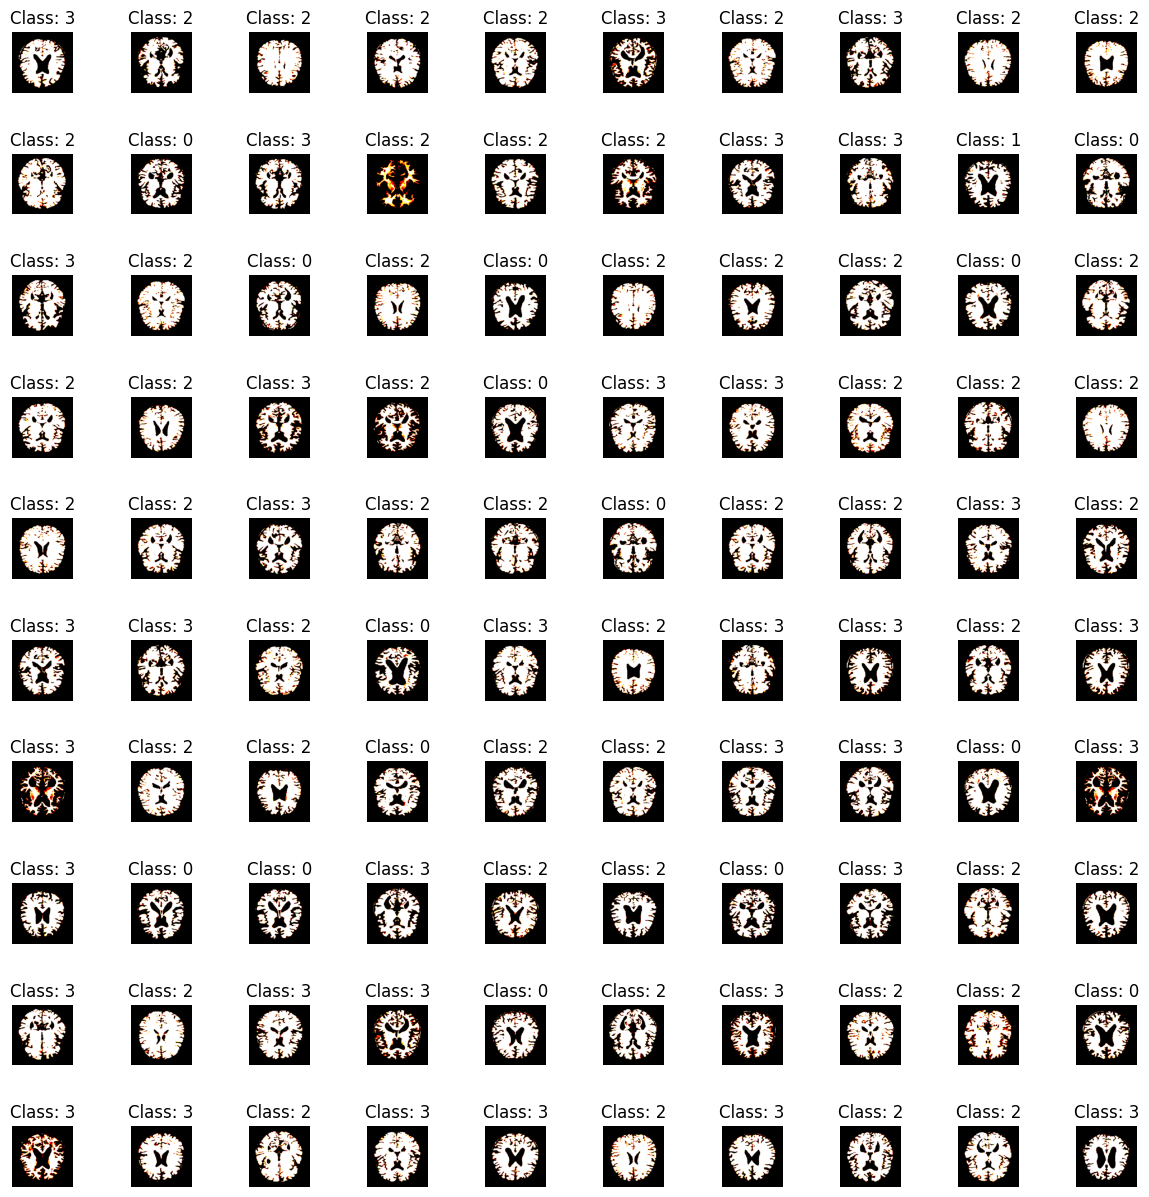

In [21]:
l = 10
w = 10

fig, axes = plt.subplots(l, w, figsize = (15,15))
axes = axes.ravel()

for i in np.arange(0, l*w):
    random_index = random.randint(0, 200)
    axes[i].imshow(images[random_index][0][0])
    axes[i].set_title(f"Class: {np.argmax(images[random_index][1][0])}")
    axes[i].axis('off')
plt.subplots_adjust(hspace=1)

In [22]:
pred = model.predict(images)
pred_classes = np.argmax(pred, axis=1)

200/200 ━━━━━━━━━━━━━━━━━━━━ 31s 136ms/step


In [23]:
true_classes = images.classes
from sklearn.metrics import accuracy_score, confusion_matrix,classification_report
accuracy_score(true_classes, pred_classes)

0.98765625

<Axes: >

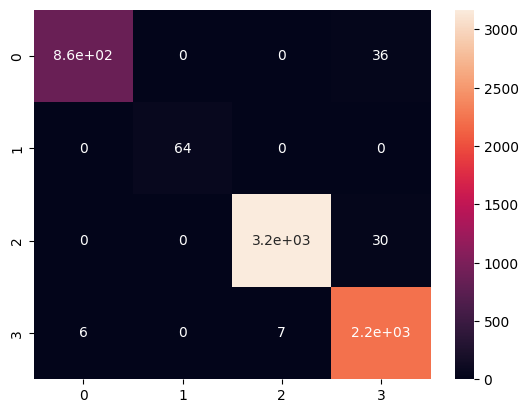

In [24]:
cm = confusion_matrix(true_classes, pred_classes)
sns.heatmap(cm, annot=True)

In [25]:
cr = classification_report(true_classes, pred_classes, target_names=images.class_indices.keys())
print(cr)

                  precision    recall  f1-score   support

    MildDemented       0.99      0.96      0.98       896
ModerateDemented       1.00      1.00      1.00        64
     NonDemented       1.00      0.99      0.99      3200
VeryMildDemented       0.97      0.99      0.98      2240

        accuracy                           0.99      6400
       macro avg       0.99      0.99      0.99      6400
    weighted avg       0.99      0.99      0.99      6400



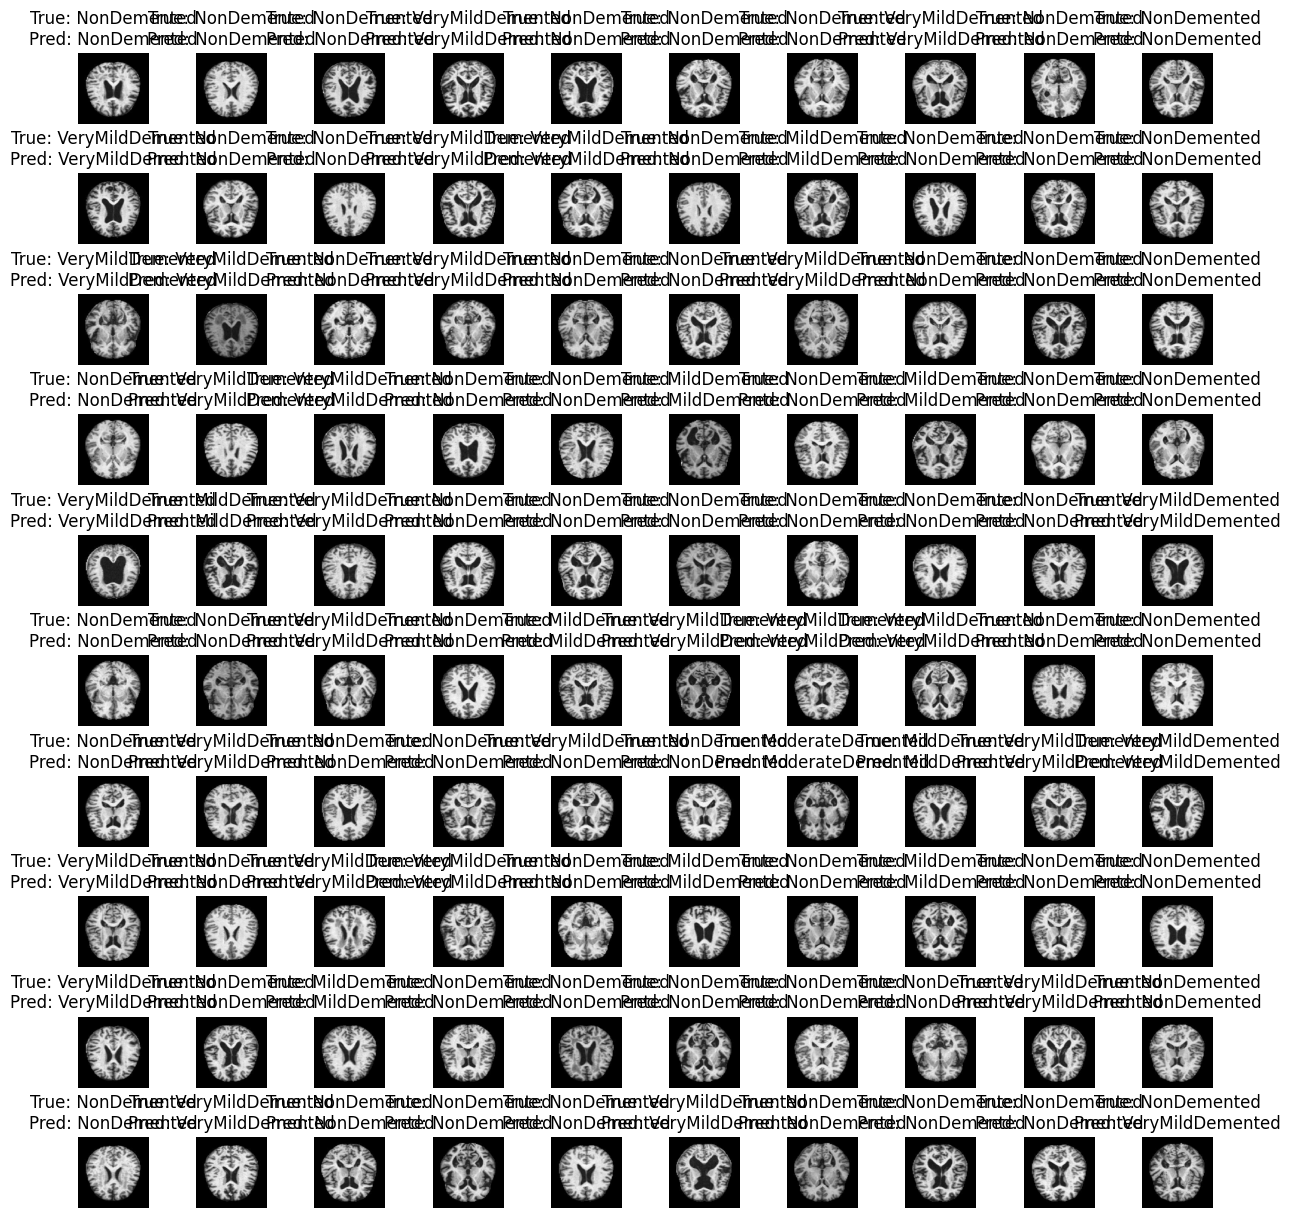

In [26]:
l = 10
w = 10

fig, axes = plt.subplots(l, w, figsize = (15,15))
axes = axes.ravel()

true_classes = images.classes
class_labels = list(images.class_indices.keys())

for i in np.arange(0, l*w):
    random_index = random.randint(0, len(pred_classes) - 1)
    img_path = images.filepaths[random_index]
    img = tf.keras.utils.load_img(img_path, target_size=(224, 224))
    img = tf.keras.utils.img_to_array(img) / 255.0 
    axes[i].imshow(img)
    axes[i].set_title(f"True: {class_labels[true_classes[random_index]]}\n"
                      f"Pred: {class_labels[pred_classes[random_index]]}")
    axes[i].axis('off')
plt.subplots_adjust(hspace=.7)

In [27]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    grad_model = tf.keras.models.Model(
        [model.inputs], 
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()


In [28]:
def display_heatmap(img_path, heatmap, alpha=0.4):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap = np.uint8(255 * heatmap)
    heatmap_color = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    superimposed_img = heatmap_color * alpha + img
    plt.imshow(superimposed_img.astype('uint8'))
    plt.axis('off')
    plt.show()


In [29]:
image = r'/kaggle/input/augmented-alzheimer-mri-dataset/OriginalDataset/MildDemented/26 (20).jpg'

In [30]:
image_loaded = tf.keras.preprocessing.image.load_img(image, target_size=(224,224))
image_array = tf.keras.preprocessing.image.img_to_array(image_loaded)
image_adjusted = np.expand_dims(image_array, axis=0)
image_adjusted = tf.keras.applications.resnet.preprocess_input(image_adjusted)

/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


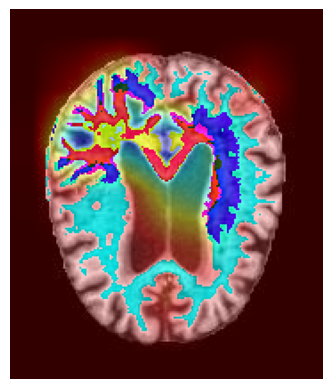

In [31]:
heatmap = make_gradcam_heatmap(image_adjusted, model, last_conv_layer_name='conv5_block3_out')
display_heatmap(image, heatmap)